In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import expon, geom, norm

In [2]:
cd_df = pd.read_csv('/kaggle/input/cardekho-used-car-data/cardekho_dataset.csv')
cd_df.head(5)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# Dataset Analysis

In [3]:
print('The size of the dataset is:',cd_df.shape)

The size of the dataset is: (15411, 14)


In [4]:
cd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
#pd.set_option('display.float_format', '{:.4f}'.format)
cd_df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


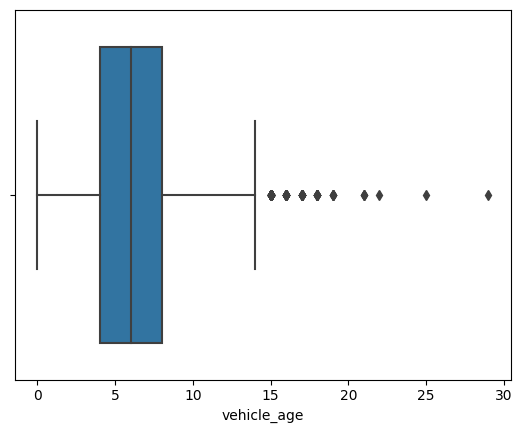

In [6]:
sns.boxplot(x = 'vehicle_age', data = cd_df)
plt.show()

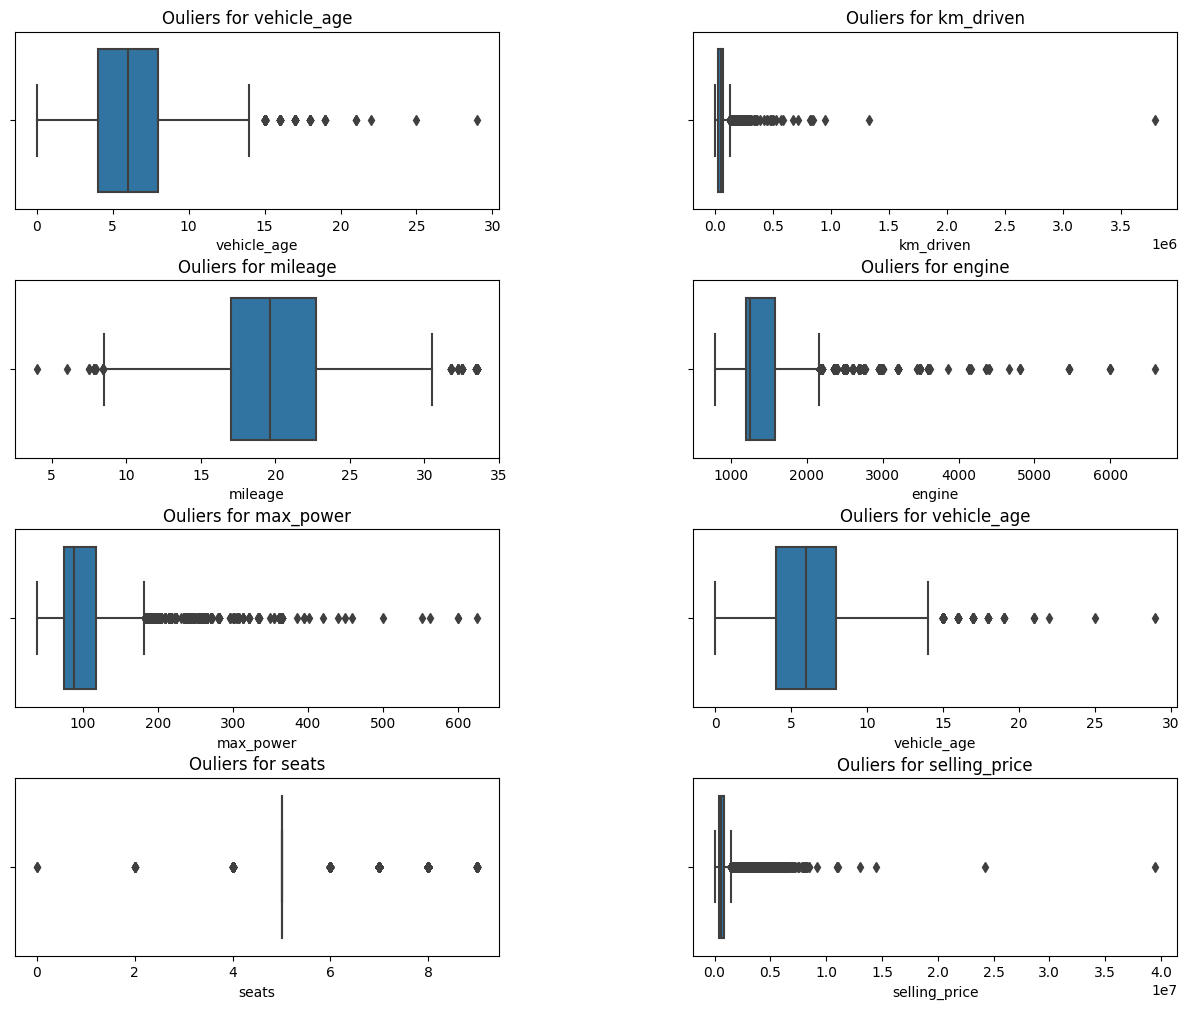

In [7]:
fig, bx = plt.subplots(nrows = 4, ncols = 2, figsize=(15,12))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)

def bxplt(col, axes):
    sns.boxplot(x = col, data = cd_df, ax = axes)
    axes.set_title(f'Ouliers for {col}')
    #axes.y

bxplt('vehicle_age', bx[0,0])
bxplt('km_driven', bx[0,1])
bxplt('mileage', bx[1,0])
bxplt('engine', bx[1,1])
bxplt('max_power', bx[2,0])
bxplt('vehicle_age', bx[2,1])
bxplt('seats', bx[3,0])
bxplt('selling_price', bx[3,1])
plt.show()

# EDA

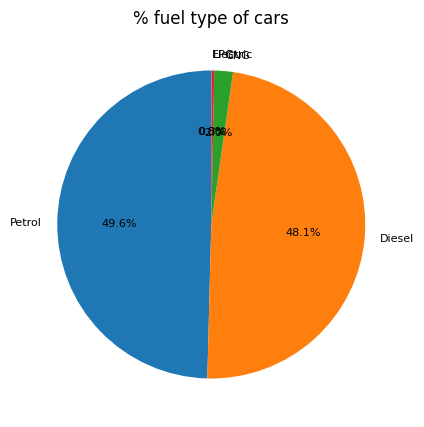

In [8]:
# % cars on which fuel type

plt.figure(figsize = (5,5))
fuel = cd_df['fuel_type'].value_counts(normalize = True) * 100
plt.pie(x = fuel.values, labels = fuel.index, startangle = 90, autopct = '%1.1f%%', textprops={'fontsize': 8})
plt.title('% fuel type of cars')
plt.show()

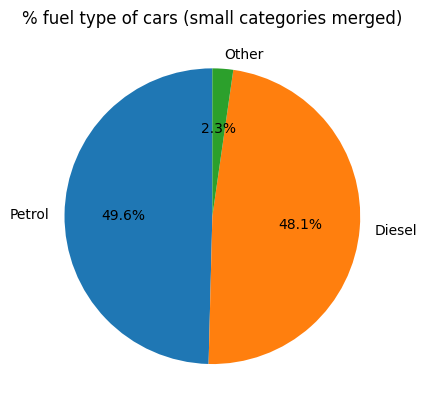

In [9]:
threshold = 5  # Merge slices below 5%
small_categories = fuel[fuel.values < threshold]
large_categories = fuel[fuel.values >= threshold]

# Combine small slices
combined_data = pd.concat([
    large_categories,
    pd.Series({"Other": small_categories.sum()})
])

plt.pie(
    x=combined_data.values, 
    labels=combined_data.index, 
    startangle=90, 
    autopct='%1.1f%%'
)
plt.title('% fuel type of cars (small categories merged)')
plt.show()

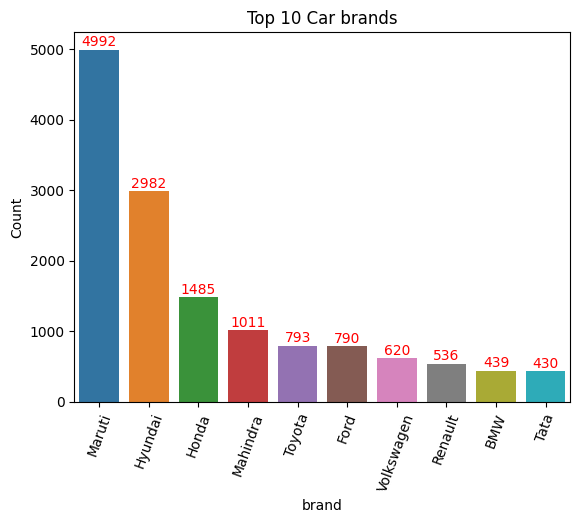

In [10]:
# Top 10 car brands
brand_name = cd_df['brand'].value_counts().head(10)#.reset_index()

x= sns.barplot(x= brand_name.index, y = brand_name.values)
for i in x.containers:
    x.bar_label(i, padding = .5, color = 'red')
plt.title('Top 10 Car brands')
plt.xticks(rotation= 70)
plt.ylabel('Count')
plt.show()

In [11]:
# From the above analysis, we can make the following observations:

print(f'1. {brand_name.index[0]} is the top brand with {brand_name.iloc[0]} cars.')
print(f'2. {brand_name.index[1]} is the 2nd brand with {brand_name.iloc[1]} cars.')
print(f'3. {brand_name.index[2]} is the 3rd brand with {brand_name.iloc[2]} cars.')
print(f'4. {brand_name.index[-1]} is a brand with lowest numbers {brand_name.iloc[-1]} cars.')

1. Maruti is the top brand with 4992 cars.
2. Hyundai is the 2nd brand with 2982 cars.
3. Honda is the 3rd brand with 1485 cars.
4. Tata is a brand with lowest numbers 430 cars.


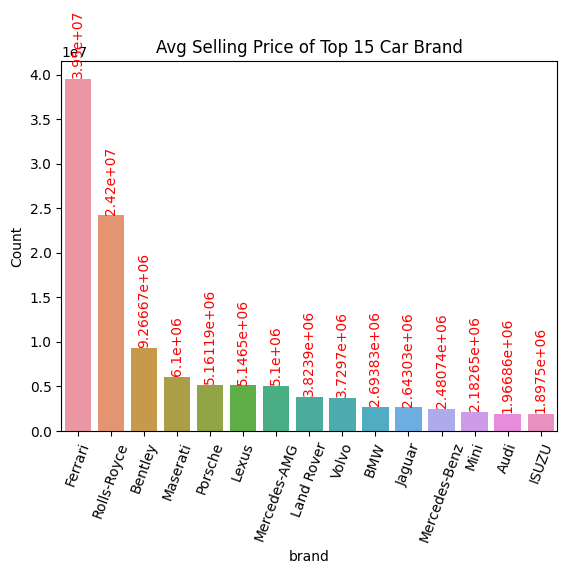

In [12]:
# Average selling price of each car brand

avg_pr = cd_df.groupby('brand')['selling_price'].mean().sort_values(ascending= False).head(15)
x = sns.barplot(x=avg_pr.index, y = avg_pr.values)
for i in x.containers:
    x.bar_label(i, padding= .5, color = 'red', rotation = 90)
plt.title('Avg Selling Price of Top 15 Car Brand')
plt.xticks(rotation= 70)
plt.ylabel('Count')
plt.show()

In [13]:
# From the above analysis, we can make the following observations:

print(f'{avg_pr.index[0]} has the highest avg. selling price {avg_pr.iloc[0]}')
print(f'{avg_pr.index[1]} has the 2nd highest avg. selling price {avg_pr.iloc[1]}')
print(f'{avg_pr.index[2]} has the 3rd highest avg. selling price {avg_pr.iloc[2]}')
print(f'{avg_pr.index[-1]} has the lowest avg. selling price {avg_pr.iloc[-1]}')

Ferrari has the highest avg. selling price 39500000.0
Rolls-Royce has the 2nd highest avg. selling price 24200000.0
Bentley has the 3rd highest avg. selling price 9266666.666666666
ISUZU has the lowest avg. selling price 1897500.0


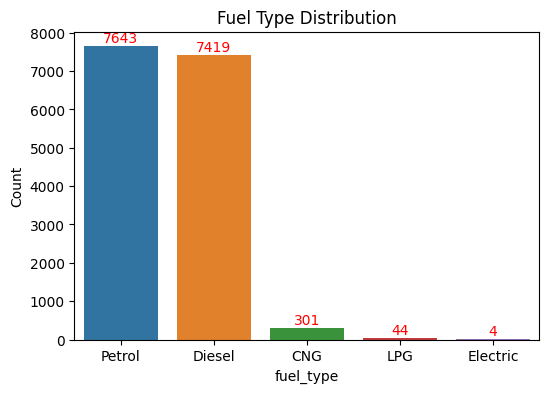

In [14]:
# fuel type distribution

fuel = cd_df['fuel_type'].value_counts().sort_values(ascending= False)
plt.figure(figsize=(6,4))
x = sns.barplot(x = fuel.index, y = fuel.values)
for i in x.containers:
    x.bar_label(i, padding = .7, color = 'red')

plt.title('Fuel Type Distribution')
plt.ylabel('Count')
plt.show()

In [15]:
# From the above analysis, we can make the following observations:

print(f'{fuel.index[0]} has the highest number of cars {fuel.iloc[0]}.')
print(f'{fuel.index[1]} has the 2nd highest number of cars {fuel.iloc[1]}.')
print(f'{fuel.index[2]} has the 3rd highest number of cars {fuel.iloc[2]}.')
print(f'{fuel.index[-1]} has the least number of cars {fuel.iloc[-1]}.')

Petrol has the highest number of cars 7643.
Diesel has the 2nd highest number of cars 7419.
CNG has the 3rd highest number of cars 301.
Electric has the least number of cars 4.


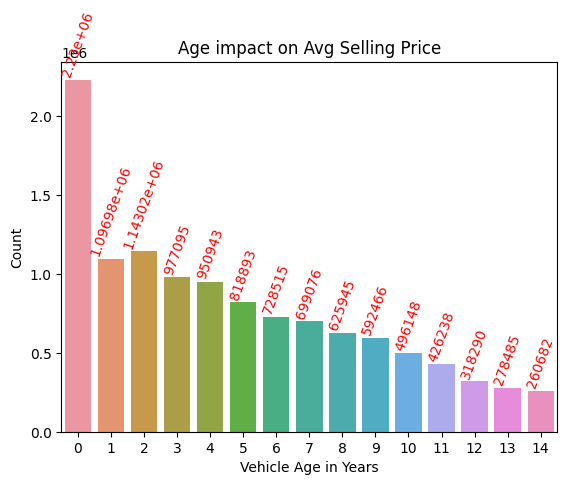

In [16]:
# vehicle age impact on avg selling price

avg_sell_pr = cd_df.groupby('vehicle_age')['selling_price'].mean().head(15)
avg_sell_pr

x = sns.barplot(x = avg_sell_pr.index, y = avg_sell_pr.values)

for i in x.containers:
    x.bar_label(i, padding = .7, color = 'red', rotation = 70)
plt.title('Age impact on Avg Selling Price')
plt.xlabel('Vehicle Age in Years')
plt.ylabel('Count')
plt.show()

In [17]:
# From the above analysis, we can make the following observations:

print(f'{avg_sell_pr.index[0]} year vehicle has avg value of {avg_sell_pr.iloc[0]}')
print(f'{avg_sell_pr.index[1]} year vehicle has avg value of {avg_sell_pr.iloc[1]}')
print(f'{avg_sell_pr.index[2]} year vehicle has avg value of {avg_sell_pr.iloc[2]}')
print(f'{avg_sell_pr.index[-1]} year vehicle has avg value of {avg_sell_pr.iloc[-1]}')

0 year vehicle has avg value of 2230000.0
1 year vehicle has avg value of 1096977.3755656108
2 year vehicle has avg value of 1143022.7074235808
14 year vehicle has avg value of 260682.17054263566


In [18]:
# Distribution based on Type of transmission

trans = cd_df['transmission_type'].value_counts()
trans

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

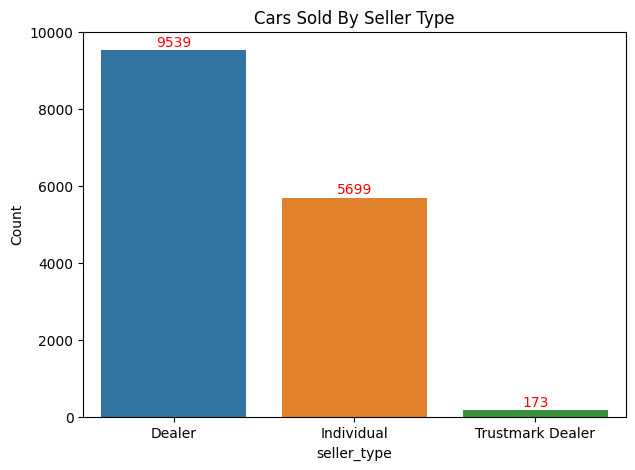

In [19]:
# Seller Types

sell_type = cd_df['seller_type'].value_counts()
plt.figure(figsize=(7,5))
x=sns.barplot(x = sell_type.index, y = sell_type.values)

for i in x.containers:
    x.bar_label(i, padding = 0.7, color = 'red')
plt.ylabel('Count')
plt.title('Cars Sold By Seller Type')
plt.show()

In [20]:
# From the above analysis, we can make the following observations:

print(f'1. {sell_type.index[0]} seller type has {sell_type.iloc[0]} cars listed.')
print(f'2. {sell_type.index[1]} seller type has {sell_type.iloc[1]} cars listed.')
print(f'3. {sell_type.index[2]} seller type has {sell_type.iloc[2]} cars listed.')

1. Dealer seller type has 9539 cars listed.
2. Individual seller type has 5699 cars listed.
3. Trustmark Dealer seller type has 173 cars listed.


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


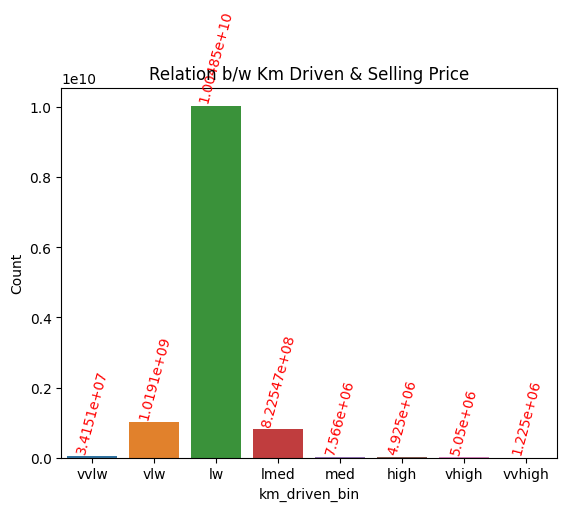

In [21]:
# 8. Relation b/w kilometers driven and selling price

km_bins = [99,1500,10000,100000, 300000, 500000, 800000, 1325001, 3800001]
km_labels = ['vvlw', 'vlw','lw','lmed', 'med', 'high', 'vhigh', 'vvhigh']

#cd_df1 = cd_df.copy()
cd_df['km_driven_bin'] = pd.cut(cd_df['km_driven'], bins = km_bins, labels = km_labels)
x1 = cd_df.groupby('km_driven_bin', observed=True)['selling_price'].sum()

k = sns.barplot(x = x1.index, y = x1.values)
for i in k.containers:
    k.bar_label(i, padding = .7, color = 'red', rotation = 75)
plt.ylabel('Count')
plt.title('Relation b/w Km Driven & Selling Price')
plt.show()

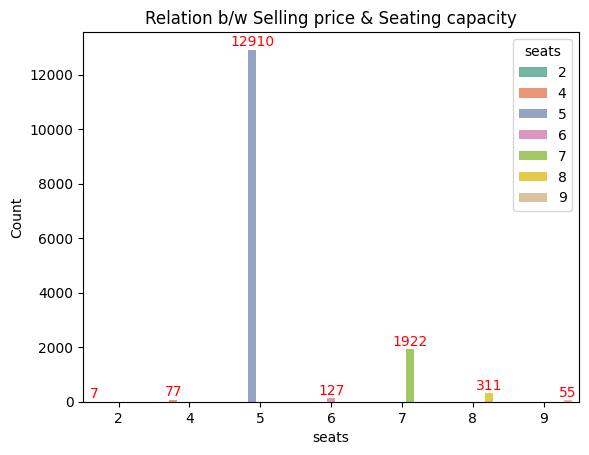

In [22]:
# Bivariate analysis
# Relation b/w seating capacity & selling price

cd_df1 = cd_df.query('seats != 0')
#cd_df1['seats']
set_sp = round((cd_df1.groupby('seats')['selling_price'].count().sort_values(ascending= False)),4)

x = sns.barplot(x = set_sp.index, y = set_sp.values, hue = set_sp.index, palette = 'Set2')

for i in x.containers:
    x.bar_label(i, padding = .5, color= 'red')

plt.title('Relation b/w Selling price & Seating capacity')
plt.ylabel('Count')
plt.show()

In [23]:
# observations from the above analysis:

print(f'{set_sp.index[0]} seater cars have the highest number of {set_sp.iloc[0]}')
print(f'{set_sp.index[1]} seater cars have the 2nd highest number of {set_sp.iloc[1]}')
print(f'{set_sp.index[-1]} seater cars have the least number {set_sp.iloc[-1]}')

5 seater cars have the highest number of 12910
7 seater cars have the 2nd highest number of 1922
2 seater cars have the least number 7


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


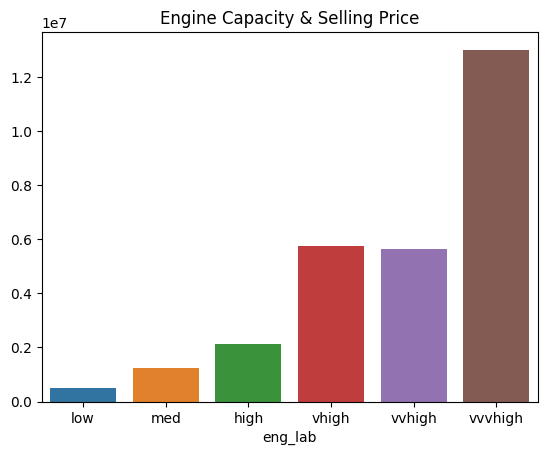

In [24]:
# Relation b/w engine capacity & selling price

eng_bins = [780, 1500, 2500, 3500, 4500, 5500, 6600]
eng_labels = ['low', 'med','high', 'vhigh','vvhigh','vvvhigh']

cd_df['eng_lab'] = pd.cut(cd_df['engine'], bins = eng_bins, labels = eng_labels)
eng = cd_df.groupby('eng_lab', observed = True)['selling_price'].mean().sort_values(ascending = False)
sns.barplot(x = eng.index, y = eng.values)
plt.title('Engine Capacity & Selling Price')
plt.show()


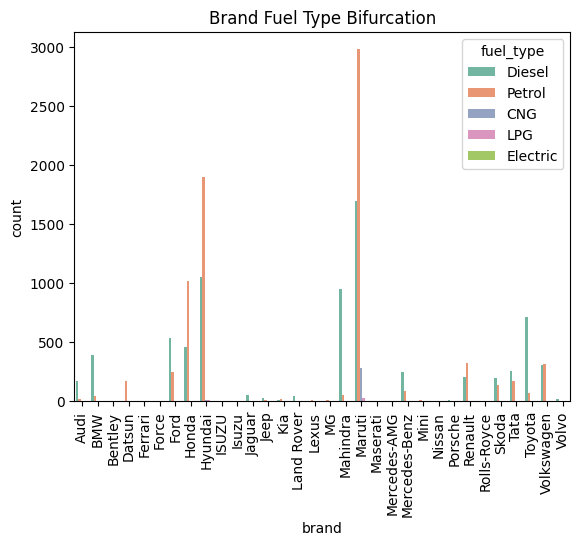

In [25]:
# brand fuel type

br_fuel_type = cd_df.groupby(['brand','fuel_type']).size().reset_index(name='count')


sns.barplot(x= 'brand', y = 'count', data= br_fuel_type ,hue = 'fuel_type', palette = 'Set2')
plt.xticks(rotation=90)
plt.title('Brand Fuel Type Bifurcation')

plt.show()

In [26]:
# 95% CI for mean car price
leng = len(cd_df['selling_price'])
cr_pr_mean = round(cd_df['selling_price'].mean(),3)
cr_pr_std = round(cd_df['selling_price'].std(),3)
mrg_err = round(1.96 * (cr_pr_std/np.sqrt(leng)), 3)

lwr_pr_lim = cr_pr_mean - mrg_err
upr_pr_lim = cr_pr_mean + mrg_err
print(f'95% CI for car price is lwr:{lwr_pr_lim}, upr: {upr_pr_lim}')

95% CI for car price is lwr:760854.177, upr: 789088.055


In [27]:
# 95% CI for milege type

def ci_milge_type(fl_type):

    fuel_type = cd_df[cd_df['fuel_type'] == fl_type]
    fuel_len = len(fuel_type)
    if fuel_len > 30:
        fuel_type_mean = round(fuel_type['mileage'].mean(), 3)
        fuel_type_std = round(fuel_type['mileage'].std(),3)
        mrg_err_fuel_type = round(1.96* (fuel_type_std/np.sqrt(fuel_len)),3)
        lwr_ci = round((fuel_type_mean - mrg_err_fuel_type),3)
        upr_ci = round((fuel_type_mean + mrg_err_fuel_type),3)
        width = round((upr_ci - lwr_ci), 3)
        print(f'lwr_ci: {lwr_ci}, upr_ci: {upr_ci}, & the width is {width}\n')
    else:
        fuel_type_mean1 = round(fuel_type['mileage'].mean(), 3)
        fuel_type_std1 = round(fuel_type['mileage'].std(),3)
        mrg_err_fuel_type1 = round(2.262 * (fuel_type_std1/np.sqrt(fuel_len)), 3)
        lwr_ci1 = round((fuel_type_mean1 - mrg_err_fuel_type1),3)
        upr_ci1 = fuel_type_mean1 + mrg_err_fuel_type1
        width1 = round((upr_ci1 - lwr_ci1), 3)
        print(f'lwr_ci: {lwr_ci1}, upr_ci: {upr_ci1}, & the width is {width1}\n')

    meen = round((fuel_type['mileage'].mean()),3)
    print(f'normal mean for {fl_type}:{meen}')
ci_milge_type('Petrol')
ci_milge_type('Electric')
ci_milge_type('Diesel')
ci_milge_type('LPG')
ci_milge_type('CNG')



lwr_ci: 19.057, upr_ci: 19.189, & the width is 0.132

normal mean for Petrol:19.123
lwr_ci: 19.16, upr_ci: 19.16, & the width is 0.0

normal mean for Electric:19.16
lwr_ci: 19.949, upr_ci: 20.171, & the width is 0.222

normal mean for Diesel:20.06
lwr_ci: 16.72, upr_ci: 18.952, & the width is 2.232

normal mean for LPG:17.836
lwr_ci: 25.177, upr_ci: 26.453, & the width is 1.276

normal mean for CNG:25.815


In [28]:
# 95% CI for seller type car price

def ci_st_cp(slltype):
    seller_type = cd_df[cd_df['seller_type'] == slltype]
    len_seller_type = len(seller_type)
    mean_seller_type = seller_type['selling_price'].mean()
    std_seller_type = seller_type['selling_price'].std()
    if len_seller_type > 30:
        mar_err_seller_type = 1.96 * (std_seller_type/np.sqrt(len_seller_type))
        lwr_ci_seller_type = round((mean_seller_type - mar_err_seller_type),3)
        upr_ci_seller_type = round((mean_seller_type + mar_err_seller_type),3)
        width = round((upr_ci_seller_type - lwr_ci_seller_type), 3 )
        print(f'lwr CI: {lwr_ci_seller_type}, upr CI: {upr_ci_seller_type}, width: {width} for {slltype}\n')
    else:
        mar_err_seller_type = 2.262 * (std_seller_type/np.sqrt(len_seller_type))
        lwr_ci_seller_type = round((mean_seller_type - mar_err_seller_type),3)
        upr_ci_seller_type = round((mean_seller_type + mar_err_seller_type),3)
        width = round((upr_ci_seller_type - lwr_ci_seller_type), 3 )
        print(f'lwr CI: {lwr_ci_seller_type}, upr CI: {upr_ci_seller_type}, width: {width} for {slltype}\n')

ci_st_cp('Individual')
ci_st_cp('Dealer')
ci_st_cp('Trustmark Dealer')

lwr CI: 602243.218, upr CI: 633517.749, width: 31274.531 for Individual

lwr CI: 851951.55, upr CI: 893059.457, width: 41107.907 for Dealer

lwr CI: 538251.594, upr CI: 605667.481, width: 67415.887 for Trustmark Dealer



In [29]:
# 95% Bootstrap CI for car selling price mean 

mean_1200 = [np.mean(np.random.choice(cd_df['selling_price'], size = 1200, replace = True)) for i in range(1200)]
lwr_1200_ci = round((np.percentile(mean_1200, 2.5)),3)
upr_1200_ci = round((np.percentile(mean_1200, 97.5)),3)
width_1200 = round((upr_1200_ci- lwr_1200_ci),3)
print(f'upr_1200_ci: {upr_1200_ci}, lwr_1200_ci: {lwr_1200_ci}, width: {width_1200}\n')

mean_1800 = [np.mean(np.random.choice(cd_df['selling_price'], size = 1200, replace = True)) for i in range(1800)]
lwr_1800_ci = round((np.percentile(mean_1800, 2.5)),3)
upr_1800_ci = round((np.percentile(mean_1800, 97.5)),3)
width_1800 = round((upr_1800_ci - lwr_1800_ci),3)
print(f'upr_1800_ci: {upr_1800_ci}, lwr_1800_ci: {lwr_1800_ci}, width: {width_1800}\n')

upr_1200_ci: 830505.687, lwr_1200_ci: 728881.979, width: 101623.708

upr_1800_ci: 828386.104, lwr_1800_ci: 727781.711, width: 100604.393



In [30]:
# CI for 50k+ driven car

less_data = cd_df[cd_df['km_driven'] <= 50000]
leng = len(less_data)
less_mean = less_data['mileage'].mean()
less_std = less_data['mileage'].std()
marg_err_less_data = 1.96 * (less_std/np.sqrt(leng))
lwr_ci_less_data = round((less_mean - less_std),3)
upr_ci_less_data = round((less_mean + less_std),3)
less_width = round((upr_ci_less_data - lwr_ci_less_data),3)

print(f'lwr_ci:{lwr_ci_less_data}, upr_ci: {upr_ci_less_data}, width:{less_width} for 50K <=.')

mre_data = cd_df[cd_df['km_driven'] > 50000]
leng1 = len(mre_data)
mre_mean = mre_data['mileage'].mean()
mre_std = mre_data['mileage'].std()
marg_err_mre_data = 1.96 * (mre_std/np.sqrt(leng1))
lwr_ci_mre_data = round((mre_mean - marg_err_mre_data), 3)
upr_ci_less_data = round((mre_mean + marg_err_mre_data),3)
mre_width = round((upr_ci_less_data - lwr_ci_mre_data),3)

print(f'lwr_ci:{lwr_ci_mre_data}, upr_ci: {upr_ci_less_data}, width:{mre_width} for 50K >.')

lwr_ci:16.201, upr_ci: 23.814, width:7.613 for 50K <=.
lwr_ci:19.273, upr_ci: 19.477, width:0.204 for 50K >.
